In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay, log_loss, ConfusionMatrixDisplay
from sklearn.metrics import f1_score, recall_score, precision_score
from sklearn.calibration import calibration_curve
from joblib import dump

In [2]:
df = pd.read_csv("C:/Users/Pratik/DS/credit-risk-ml/data/processed/credit_features_v1.csv")

In [3]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,...,ANNUITY_INCOME_RATIO,GOODS_CREDIT_RATIO,CHILDREN_RATIO,HAS_CHILDREN,IS_SINGLE,HAS_CAR,HAS_REALTY,LONG_EMPLOYED,NAME_EDUCATION_ENC,INCOME_GROUP
0,100002,1,Cash loans,M,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,...,0.121978,0.863262,0.0,0,1,0,1,0.0,1,Employed
1,100003,0,Cash loans,F,0,270000.0,1293502.5,35698.5,1129500.0,Family,...,0.132217,0.873211,0.0,0,0,0,0,0.0,3,Employed
2,100004,0,Revolving loans,M,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,...,0.100000,1.000000,0.0,0,1,1,1,0.0,1,Employed
3,100006,0,Cash loans,F,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,...,0.219900,0.949845,0.0,0,0,0,1,0.0,1,Employed
4,100007,0,Cash loans,M,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,...,0.179963,1.000000,0.0,0,1,0,1,0.0,1,Employed


In [4]:
df.isnull().sum()

SK_ID_CURR            0
TARGET                0
NAME_CONTRACT_TYPE    0
CODE_GENDER           0
CNT_CHILDREN          0
                     ..
HAS_CAR               0
HAS_REALTY            0
LONG_EMPLOYED         0
NAME_EDUCATION_ENC    0
INCOME_GROUP          0
Length: 135, dtype: int64

In [5]:
# Drop Columns for V1
df.drop(columns=['NAME_INCOME_TYPE','OCCUPATION_TYPE','NAME_TYPE_SUITE','HOUSETYPE_MODE','WALLSMATERIAL_MODE','EMERGENCYSTATE_MODE','FONDKAPREMONT_MODE'],inplace=True)

#### Test-Train Split

In [6]:
# Split 
X = df.drop(columns=['TARGET'])
y = df['TARGET']

X_train , X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [7]:
# Risk Features 
income_risk_map = (X_train.assign(TARGET=y_train).groupby('INCOME_GROUP')['TARGET'].mean())
org_risk_map = (X_train.assign(TARGET=y_train).groupby('ORGANIZATION_TYPE')['TARGET'].mean())

X_train['INCOME_RISK'] = X_train['INCOME_GROUP'].map(income_risk_map)
X_test['INCOME_RISK'] = X_test['INCOME_GROUP'].map(income_risk_map)
X_train['ORG_RISK'] = X_train['ORGANIZATION_TYPE'].map(org_risk_map)
X_test['ORG_RISK'] = X_test['ORGANIZATION_TYPE'].map(org_risk_map)

# Drop Columns No Longer Needed
X_train = X_train.drop(columns=['INCOME_GROUP','ORGANIZATION_TYPE'])
X_test  = X_test.drop(columns=['INCOME_GROUP','ORGANIZATION_TYPE'])

# Saving Test Data
dump((X_test, y_test),"C:/Users/Pratik/DS/credit-risk-ml/models/test_data.joblib")

['C:/Users/Pratik/DS/credit-risk-ml/models/test_data.joblib']

#### Baseline Model: Logistic Regression

In [8]:
num_features = [
    'AMT_INCOME_TOTAL',
    'AGE_YEARS',
    'EMPLOYED_YEARS',
    'EXT_SOURCE_1',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3',
    'INCOME_RISK',
    'ORG_RISK'
]

bin_features = [
    'HAS_CHILDREN',
    'IS_SINGLE',
    'HAS_CAR',
    'HAS_REALTY',
    'LONG_EMPLOYED'
]

cat_features = [
    'NAME_CONTRACT_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'CODE_GENDER',
    'WEEKDAY_APPR_PROCESS_START'
]


In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_features)
    ],
    remainder='passthrough'
)

In [10]:
model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        solver='liblinear',
    ))
])
model.fit(X_train, y_train)
dump(model, "C:/Users/Pratik/DS/credit-risk-ml/models/logres_baseline.joblib")

fitted_preprocessor = model.named_steps["preprocess"]
dump(fitted_preprocessor, "C:/Users/Pratik/DS/credit-risk-ml/models/preprocessor_fit.joblib")

['C:/Users/Pratik/DS/credit-risk-ml/models/preprocessor_fit.joblib']

#### Model Performance (Probabilistic Metrics)

In [11]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("ROC-AUC:\n", roc_auc_score(y_test, y_proba))
print('Log-Loss:',log_loss(y_test, y_proba))
print(classification_report(y_test, y_pred))

ROC-AUC:
 0.7433043010009185
Log-Loss: 0.5975847189446115
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56538
           1       0.16      0.67      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503



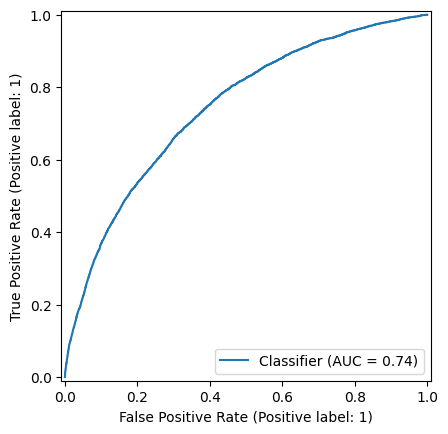

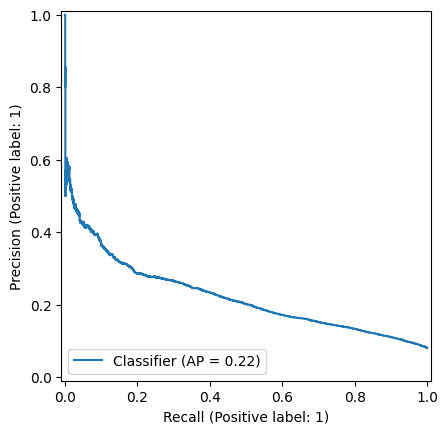

In [12]:
roc_disp = RocCurveDisplay.from_predictions(y_test, y_proba)
plt.savefig('C:/Users/Pratik/DS/credit-risk-ml/reports/figures/roc_disp.png',dpi=300,bbox_inches='tight')
plt.show()

prd = PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.savefig('C:/Users/Pratik/DS/credit-risk-ml/reports/figures/precision_recall_disp.png',dpi=300,bbox_inches='tight')
plt.show()

 ROC - ranking quality , PR - performance on minority (defaulters)

#### Classification Performance (Threshold-Based)

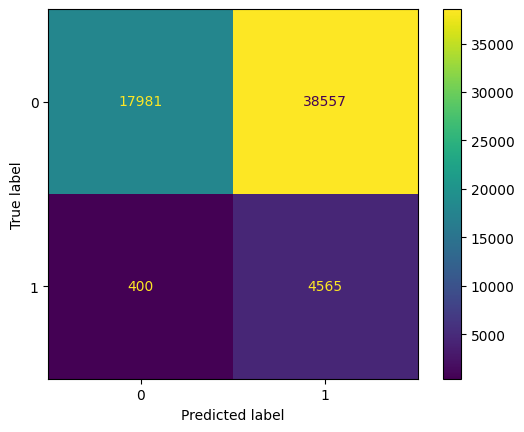

In [13]:
threshold = 0.3
y_pred_label = (y_proba >= threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_label)
ConfusionMatrixDisplay(cm).plot()

In credit risk, minimizing false negative is often more important than accuracy. Therefore, decision thresholds are evaluated separately from the model’s probabilistic output

#### Optimal Threshold

In [14]:
thresholds = np.linspace(0.05, 0.95, 50)

results = []
for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    results.append({
        "threshold": t,
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

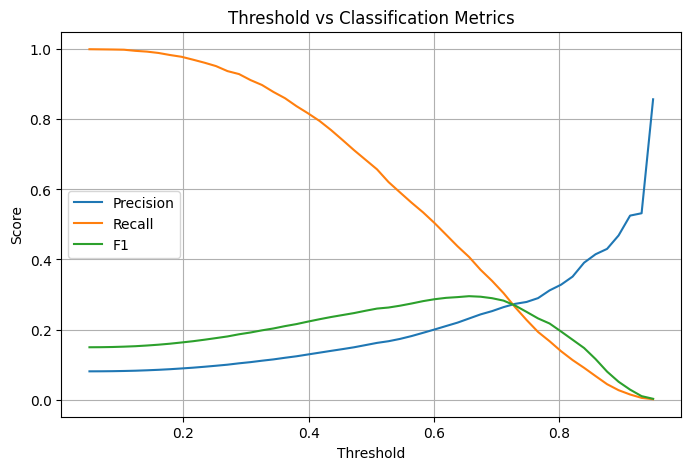

In [15]:
plt.figure(figsize=(8,5))
plt.plot(results_df["threshold"], results_df["precision"], label="Precision")
plt.plot(results_df["threshold"], results_df["recall"], label="Recall")
plt.plot(results_df["threshold"], results_df["f1"], label="F1")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Classification Metrics")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
optimal_threshold = results_df.loc[results_df["f1"].idxmax(), "threshold"]
optimal_threshold

np.float64(0.6561224489795918)

We select the threshold that maximizes F1, balancing false approvals and false rejections

#### Confusion Matrix with Optimal Threshold

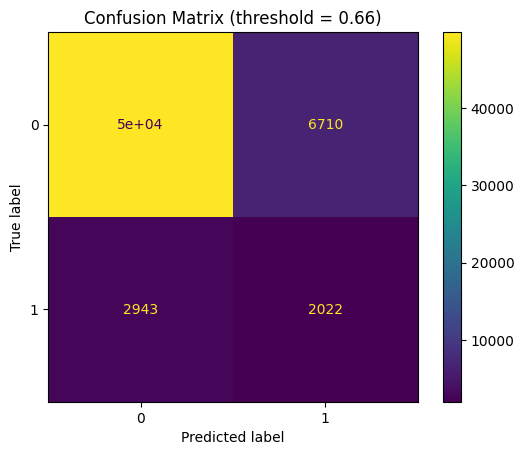

In [17]:

y_pred_opt = (y_proba >= optimal_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_opt)

ConfusionMatrixDisplay(cm).plot()
plt.title(f"Confusion Matrix (threshold = {optimal_threshold:.2f})")
plt.savefig('C:/Users/Pratik/DS/credit-risk-ml/reports/figures/optimal_threshold_CM.png',dpi=300,bbox_inches='tight')
plt.show()

#### Top Features Driving Model Predictions

In [18]:
feature_names = (
    model.named_steps['preprocess']
    .get_feature_names_out()
)

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': model.named_steps['clf'].coef_[0]
}).sort_values(by='coefficient', ascending=False)

coef_df.head(15)

,feature,coefficient
7,num__ORG_RISK,0.139302
2,num__EMPLOYED_YEARS,0.138417
23,cat__CODE_GENDER_M,0.108232
48,remainder__REGION_RATING_CLIENT_W_CITY,0.067265
105,remainder__FLAG_DOCUMENT_3,0.059484
100,remainder__DEF_30_CNT_SOCIAL_CIRCLE,0.058530
47,remainder__REGION_RATING_CLIENT,0.058372
12,cat__NAME_EDUCATION_TYPE_Secondary / secondary...,0.057511
42,remainder__FLAG_WORK_PHONE,0.049952
102,remainder__DEF_60_CNT_SOCIAL_CIRCLE,0.049823


#### Business Interpretation

Text(0.5, 1.0, 'Predicted Default Probability Distribution')

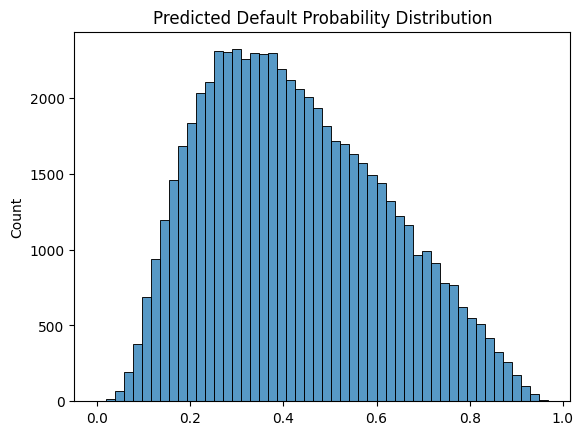

In [19]:
sns.histplot(y_proba, bins=50)
plt.title("Predicted Default Probability Distribution")

Text(0.5, 1.0, 'Calibration Curve (Baseline)')

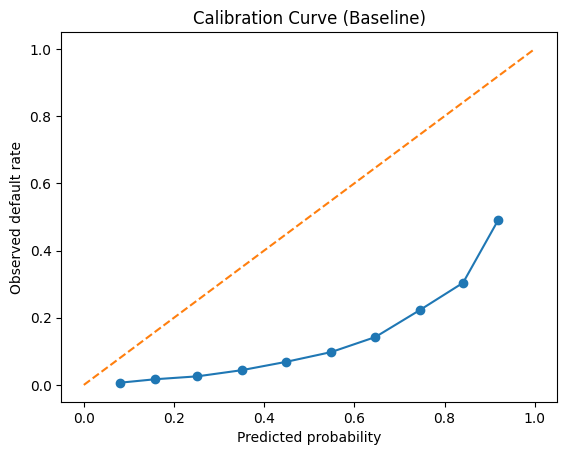

In [20]:
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--')
plt.xlabel("Predicted probability")
plt.ylabel("Observed default rate")
plt.title("Calibration Curve (Baseline)")

Shows overconfidence

In [21]:
example_df = X_test.copy()
example_df['actual'] = y_test
example_df['pred_proba'] = y_proba
example_df.sort_values('pred_proba', ascending=False).head(10)

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,...,HAS_CHILDREN,IS_SINGLE,HAS_CAR,HAS_REALTY,LONG_EMPLOYED,NAME_EDUCATION_ENC,INCOME_RISK,ORG_RISK,actual,pred_proba
194770,325842,Cash loans,M,0,135000.0,407727.0,29799.0,333000.0,Secondary / secondary special,Single / not married,...,0,1,0,1,0.0,1,0.086655,0.090930,1,0.967710
279148,423384,Cash loans,F,0,112500.0,601470.0,32760.0,450000.0,Secondary / secondary special,Civil marriage,...,0,0,0,1,0.0,1,0.086655,0.092733,1,0.960102
110004,227581,Cash loans,F,0,69750.0,900000.0,26316.0,900000.0,Secondary / secondary special,Married,...,0,0,0,0,0.0,1,0.086655,0.102120,1,0.959354
182030,310987,Cash loans,M,0,180000.0,640080.0,31261.5,450000.0,Secondary / secondary special,Civil marriage,...,0,0,0,1,0.0,1,0.086655,0.119467,1,0.955245
116533,235139,Cash loans,M,0,99000.0,106659.0,8554.5,81000.0,Secondary / secondary special,Single / not married,...,0,1,0,0,0.0,1,0.086655,0.070588,0,0.954161
202181,334370,Cash loans,F,0,135000.0,343800.0,16852.5,225000.0,Secondary / secondary special,Single / not married,...,0,1,0,1,0.0,1,0.086655,0.119467,1,0.952385
237387,374966,Cash loans,F,1,81000.0,481320.0,13923.0,315000.0,Secondary / secondary special,Married,...,1,0,0,1,0.0,1,0.086655,0.090930,1,0.952034
114012,232225,Cash loans,M,0,157500.0,302544.0,14845.5,198000.0,Secondary / secondary special,Separated,...,0,1,1,1,0.0,1,0.086655,0.157676,0,0.949183
281602,426225,Cash loans,F,0,157500.0,1256400.0,44644.5,900000.0,Secondary / secondary special,Separated,...,0,1,0,1,0.0,1,0.086655,0.092733,0,0.948900
190137,320459,Cash loans,M,0,198000.0,746280.0,58963.5,675000.0,Secondary / secondary special,Single / not married,...,0,1,0,0,0.0,1,0.086655,0.080498,0,0.947526


### Baseline Model Summary

A Logistic Regression model with class-balanced loss was trained as a baseline credit risk model.
The model outputs calibrated probabilities of default, which are converted into binary decisions
using an optimized threshold.

Key takeaways:
- The model ranks defaulters effectively (ROC-AUC)
- Probability outputs enable flexible risk-based decision making
- Threshold selection significantly impacts false approval vs rejection trade-offs

This baseline establishes a reference point for more complex models and uncertainty-aware approaches.